Comparison between our conditional metrics bounds and Eq. (11) bounds from 

_An adaptive nearest neighbor rule for classification_. Akshay Balsubramani, Sanjoy Dasgupta, Yoav Freund and Shay Moran. Advances in Neural Information Processing Systems 32 (NeurIPS 2019).

In [1]:
%run -i ../python_scripts/nb_setup.py

GPU Available: False


In [2]:
from python_scripts.sgp_utils import (
    bound,
    B_star,
    emp_errs_count,
    emp_metric,
    our_bound,
)

In [3]:
datasets = [
    "../experiments/CIFAR/sgp_set_cnn",
    "../experiments/CIFAR/sgp_set_resnet",
    "../experiments/CIFAR/sgp_set_cnn_MCD",
    "../experiments/WSI/sgp_set_cnn",
    "../experiments/WSI/sgp_set_cnn_MCD",
]

In [4]:
delta = 5e-3  # same fixed delta as in all other experiments
k2 = 50  # grid size

In [5]:
res_dicos = []
for dataset in datasets:

    print(dataset)

    data = "CIFAR" if ("CIFAR" in dataset) else "WSI"
    model = "cnn" if ("cnn" in dataset) else "resnet"
    kappa = "MCD" if ("MCD" in dataset) else "SR"

    dataset = pickle.load(open(dataset, "rb"))

    train_set = dataset.iloc[: int(3 * len(dataset) / 4)]
    train_set = (
        train_set.sort_values("kappa", ascending=True).reset_index(drop=True).copy()
    )
    test_set = dataset.iloc[int(3 * len(dataset) / 4) :]

    thetas = (
        np.linspace(0.5, 0.95, k2) if (kappa == "SR") else np.linspace(-0.05, 0, k2)
    )

    for metric in ["FPR", "FNR"]:

        print(metric)

        our_bounds = []
        eq11_bounds = []
        test_metrics = []

        for theta in tqdm(thetas):
            selected_samples = train_set.loc[train_set.kappa >= theta].copy()
            our_bounds.append(
                our_bound(selected_samples, metric, delta, n=train_set.shape[0])
            )

            # Bound from eq (11)
            eq11_bounds.append(eq11_bound(selected_samples, metric, delta))

            try:
                # test metric
                test_metrics.append(
                    emp_metric(
                        test_set.loc[test_set.kappa >= theta].copy(), metric=metric
                    )
                )
            except ValueError:
                test_metrics.append(np.nan)

        res_dicos.append(
            {
                "data": data,
                "model": model,
                "kappa": kappa,
                "metric": metric,
                "our_bounds": our_bounds,
                "eq11_bounds": eq11_bounds,
                "test_metrics": test_metrics,
            }
        )

../experiments/CIFAR/sgp_set_cnn
FPR


100%|██████████| 50/50 [00:33<00:00,  1.49it/s]


FNR


100%|██████████| 50/50 [00:08<00:00,  6.24it/s]


../experiments/CIFAR/sgp_set_resnet
FPR


...

100%|██████████| 50/50 [00:00<00:00, 104.42it/s]


../experiments/WSI/sgp_set_cnn_MCD
FPR


100%|██████████| 50/50 [00:04<00:00, 10.50it/s]


FNR


100%|██████████| 50/50 [00:00<00:00, 63.08it/s]


In [6]:
df = pd.DataFrame(res_dicos)

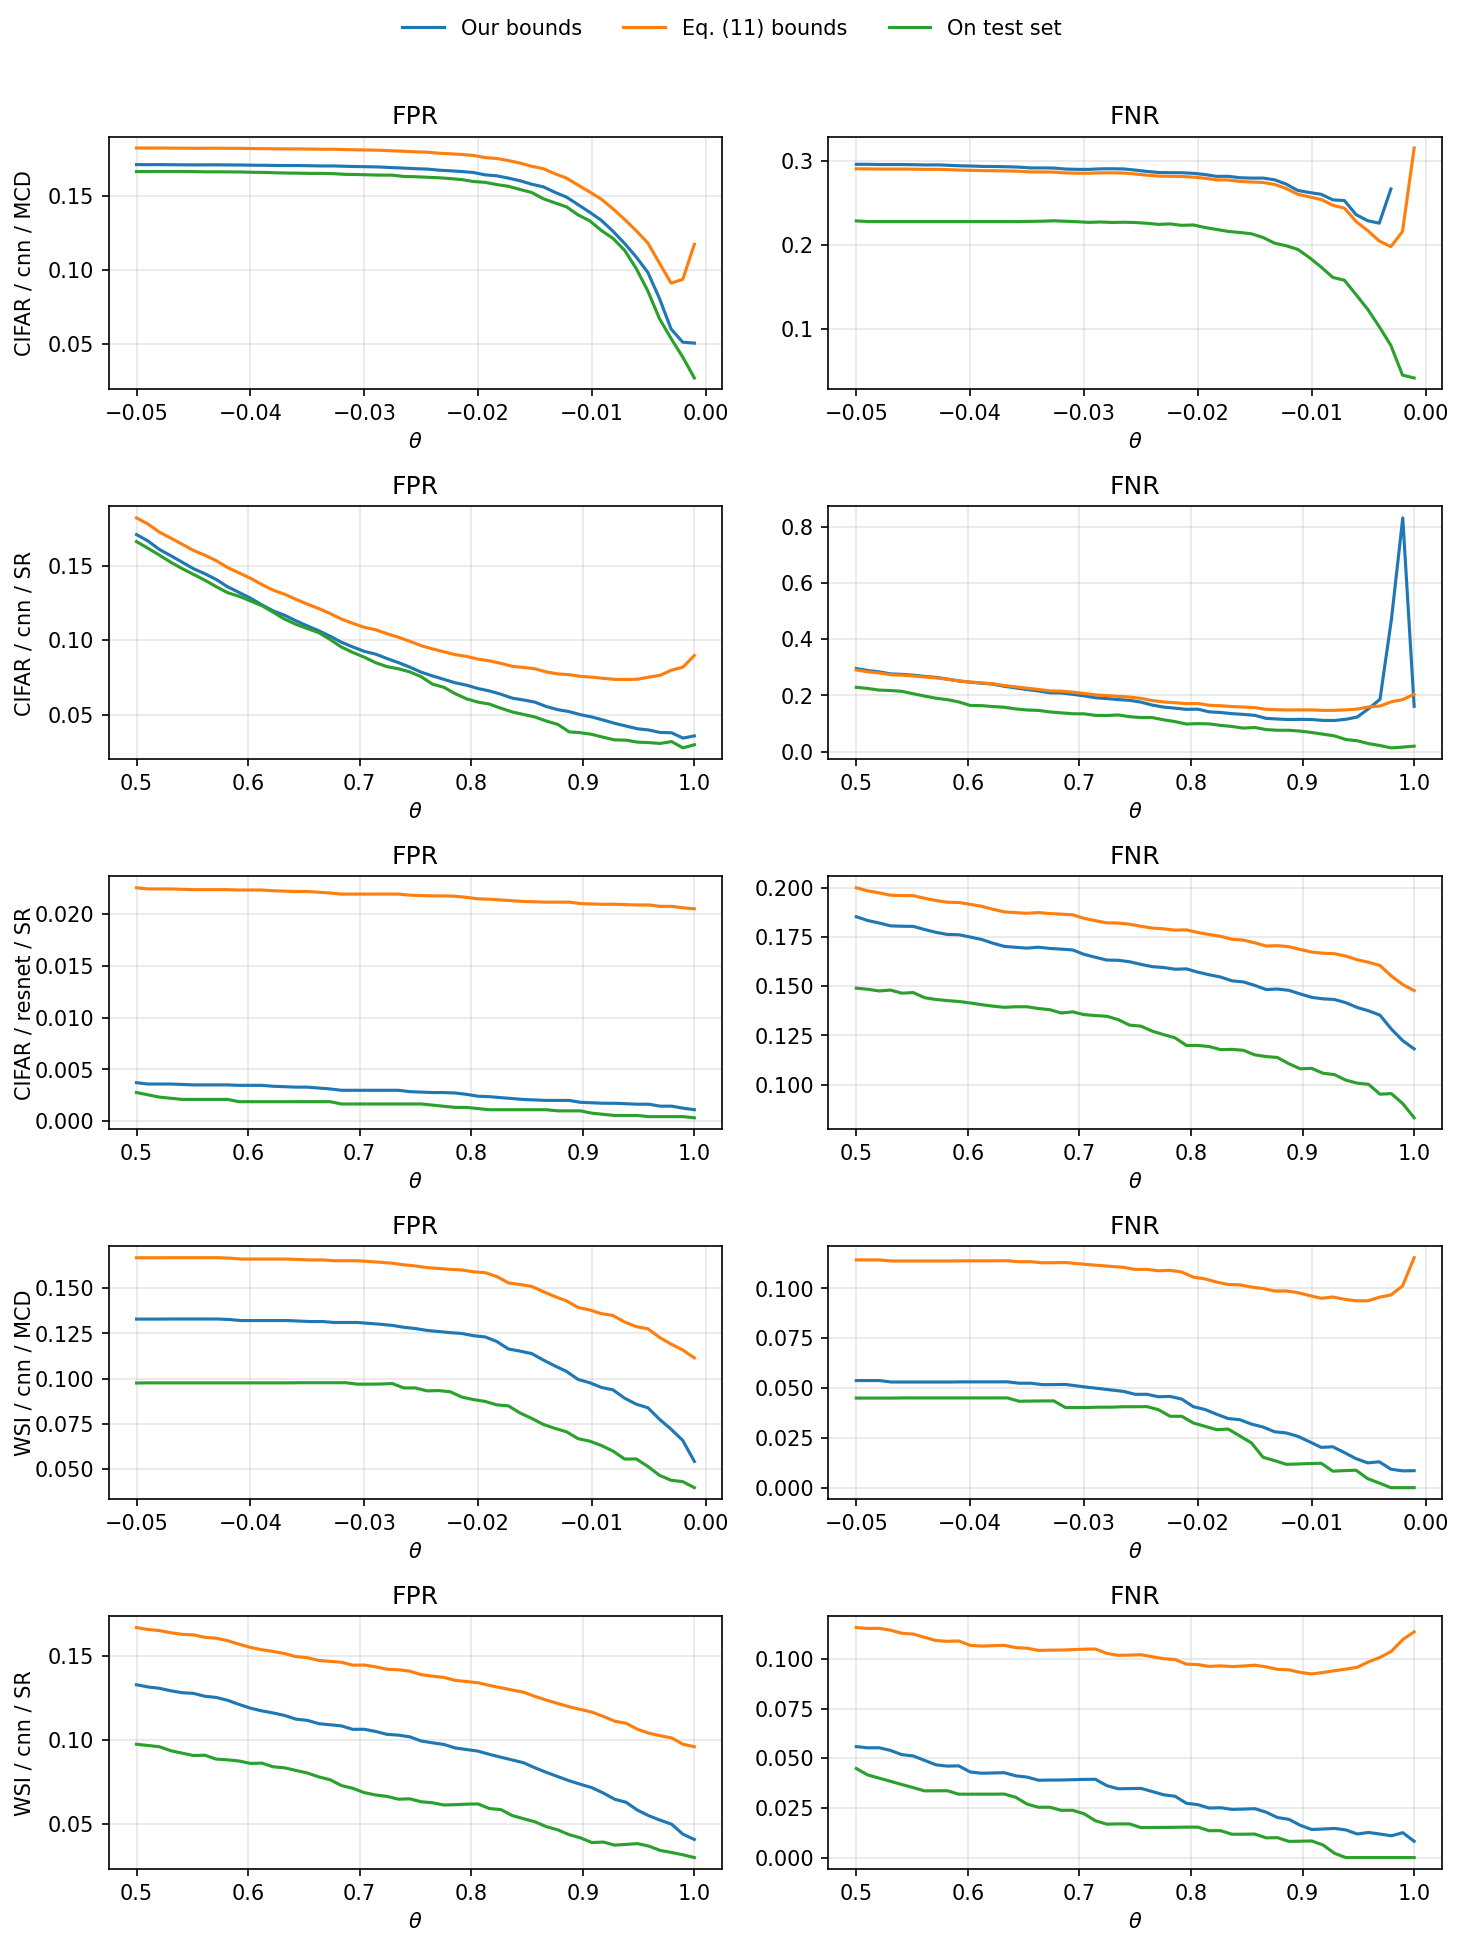

In [7]:
# --- layout: one row per (data, model, kappa)
metrics_order = ["FPR", "FNR"]
combos = (
    df[["data", "model", "kappa"]]
    .drop_duplicates()
    .sort_values(["data", "model", "kappa"])
    .itertuples(index=False, name=None)
)
combos = list(combos)
nrows = len(combos)
ncols = len(metrics_order)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4.9 * ncols, 2.6 * nrows), squeeze=False
)

series_cols = ["our_bounds", "eq11_bounds", "test_metrics"]
label_map = {
    "our_bounds": "Our bounds",
    "eq11_bounds": "Eq. (11) bounds",
    "test_metrics": "On test set",
}


for r, (data, model, kappa) in enumerate(combos):
    # x is shared across the row and depends on kappa
    x = np.linspace(0.5, 1, 50) if kappa == "SR" else np.linspace(-0.05, 0, 50)

    sub = df[(df["data"] == data) & (df["model"] == model) & (df["kappa"] == kappa)]

    for c, metric in enumerate(metrics_order):
        ax = axes[r, c]
        row = sub[sub["metric"] == metric]
        if row.empty:
            ax.set_axis_off()
            continue

        row = row.iloc[0]

        for sc in series_cols:
            y = np.asarray(row[sc], dtype=float)
            ax.plot(x, y, label=label_map[sc])

        ax.set_title(metric)
        ax.set_xlabel(r"$\theta$")
        ax.grid(True, alpha=0.3)

        # Put the row label on the left-most subplot
        if c == 0:
            ax.text(
                -0.12,
                0.5,
                f"{data} / {model} / {kappa}",
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="right",
            )

# one shared legend (top)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()